In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import seaborn as sns

In [ ]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 151 (delta 47), reused 21 (delta 2), pack-reused 18 (from 2)
Receiving objects: 100% (151/151), 209.68 MiB | 15.54 MiB/s, done.
Resolving deltas: 100% (47/47), done.
Updating files: 100% (45/45), done.
Filtering content: 100% (14/14), 1.29 GiB | 65.40 MiB/s, done.
Encountered 2 file(s) that should have been pointers, but weren't:
	PreProcessedData/quicknet_test.pkl
	PreProcessedData/quicknet_train.pkl
/content/PRMLProject


In [ ]:
def unpickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f)

In [ ]:
X_train_knn_raw=unpickle("PreProcessedData/RawPixels_train.pkl")
print(X_train_knn_raw.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_knn_raw=unpickle("PreProcessedData/RawPixels_test.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 32, 32, 3)
(50000,)


In [ ]:
# Flattening the image
X_train_knn_raw = X_train_knn_raw.reshape(50000, -1)
X_test_knn_raw = X_test_knn_raw.reshape(10000, -1)

print(X_train_knn_raw.shape)
print(X_test_knn_raw.shape)

(50000, 3072)
(10000, 3072)


Writing our own KNN Implementation

In [ ]:
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def find_knn(k=10, X_train=X_train_knn_raw, X_test=X_test_knn_raw, y_train=y_train, y_test=y_test):
    results = []

    for idx, test_sample in enumerate(tqdm(X_test)):
        # Computing distances in a vectorized way
        distances = np.linalg.norm(X_train - test_sample, axis=1)

        # To Get indices of k smallest distances
        k_nearest_indices = np.argsort(distances)[:k]

        # To Get labels of k nearest neighbors
        k_labels = y_train[k_nearest_indices]

        # Majority vote for classification
        predicted_label = Counter(k_labels).most_common(1)[0][0]
        results.append(predicted_label)

    #Accuracy
    accuracy = accuracy_score(y_test, results)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Computing confusion matrix
    conf_matrix = confusion_matrix(y_test, results)
    print("Confusion Matrix:\n", conf_matrix)

    # Plotting confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()



100%|██████████| 10000/10000 [2:40:40<00:00,  1.04it/s]


Accuracy: 22.00%
Confusion Matrix:
 [[656  13  65  15  39  20  19   7 163   3]
 [307  57  78  48  85  74  20  31 287  13]
 [364   3 302  51  98  73  21   4  83   1]
 [297   7 157 144  74 159  43  11 102   6]
 [300   1 273  38 193  62  20   7 106   0]
 [312   2 154 126  69 192  44  15  80   6]
 [199   4 264  59 131 148  83   6 105   1]
 [299   4 136  57 183  96  38  73 106   8]
 [375  12  31  18  35  30  10   9 473   7]
 [264  45  73  43  67 111  32  38 300  27]]


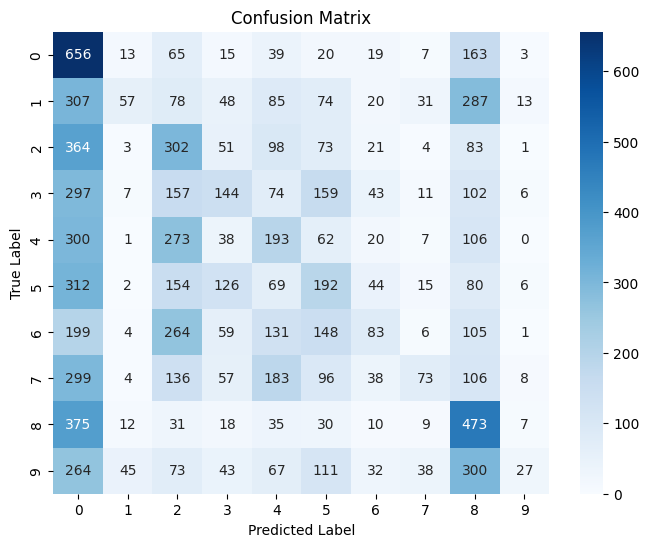

In [7]:
find_knn()

using SkLearn Library with Euclidean as the distance metric

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def find_knn1(k=10, X_train=X_train_knn_raw, X_test=X_test_knn_raw, y_train=y_train, y_test=y_test):
    # Initializing k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    # Traiing the model
    knn.fit(X_train, y_train)

    # Predicting on test data
    y_pred = knn.predict(X_test)

    # Computing and printing accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Computing and printing confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plotting confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


Accuracy: 33.86%
Confusion Matrix:
 [[510   3 109  16  57   4  26   6 269   0]
 [109 183 135  35 183  25  69   6 237  18]
 [100   1 438  38 267  33  54   7  60   2]
 [ 55   3 230 189 231 101 126  10  51   4]
 [ 58   0 265  20 539  13  42  13  50   0]
 [ 45   2 200 140 227 224  87  13  57   5]
 [ 15   0 271  54 343  31 257   0  28   1]
 [ 76   4 183  50 305  55  50 197  73   7]
 [109   6  46  36  67  15  12   6 699   4]
 [127  36 102  48 130  20  55  17 315 150]]


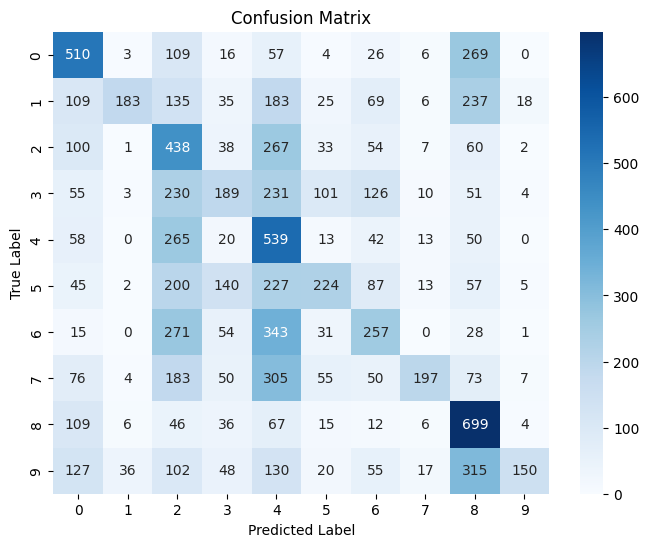

In [12]:
find_knn1()

using SkLearn Library with Manhattan as the distance metric

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn2(k=10, X_train=X_train_knn_raw, X_test=X_test_knn_raw, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Manhattan distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


Accuracy: 38.10%
Confusion Matrix:
 [[581   4  94  11  52   3  28   6 212   9]
 [ 93 248 120  40 150  32  65  13 198  41]
 [119   3 465  44 234  21  55  11  46   2]
 [ 69   5 211 216 195  98 119  19  60   8]
 [ 79   1 264  25 518  16  41  13  43   0]
 [ 62   4 211 130 172 280  74  10  52   5]
 [ 26   2 267  46 296  25 305   1  31   1]
 [ 88   7 164  47 288  47  44 251  51  13]
 [122  12  30  33  58  16   8   9 700  12]
 [145  75  68  42 104  21  48  27 224 246]]


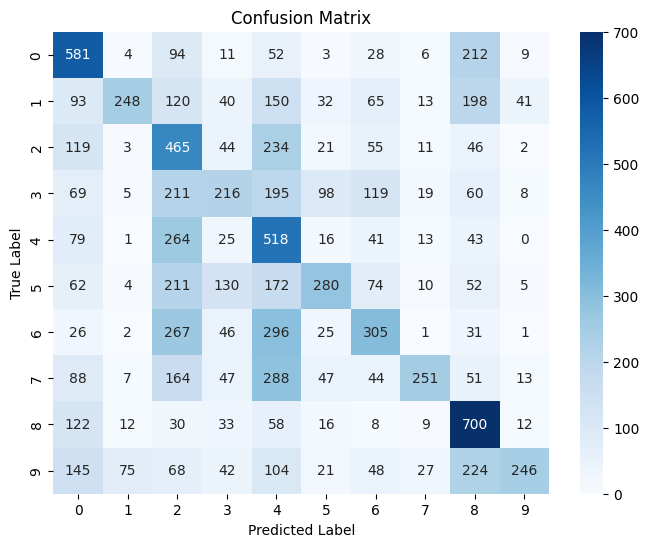

In [14]:
find_knn2()

using SkLearn Library with Canberra as the distance metric

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn3(k=10, X_train=X_train_knn_raw, X_test=X_test_knn_raw, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Canberra distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='canberra')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


Accuracy: 36.10%
Confusion Matrix:
 [[625   1  89   6  56   1  18   3 197   4]
 [116 205 103  39 169  29  61  15 238  25]
 [147   5 473  40 214  25  41  10  44   1]
 [ 86   7 222 187 204 106 111  14  57   6]
 [ 78   1 293  14 500  12  41  14  47   0]
 [ 81   3 208 119 180 268  58  23  58   2]
 [ 31   2 293  41 302  36 259   2  31   3]
 [112   4 178  44 298  38  41 226  54   5]
 [132   9  42  23  61  11  10   6 703   3]
 [161  36  87  43 119  27  47  33 283 164]]


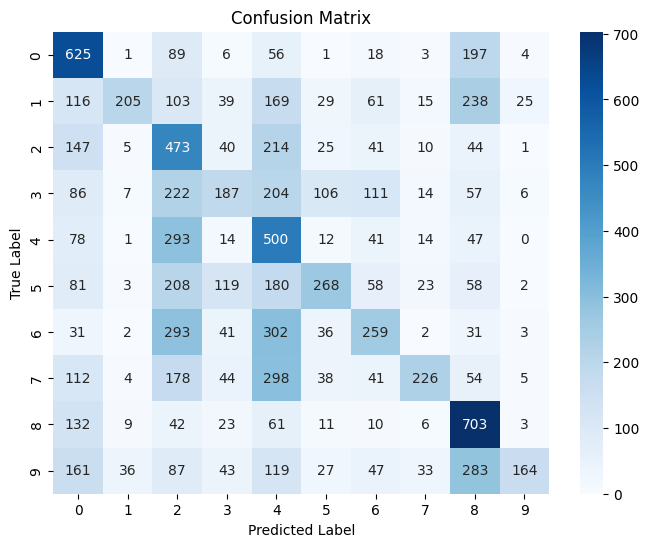

In [16]:
find_knn3()

using SkLearn Library with Bray Curtis as the distance metric

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn4(k=10, X_train=X_train_knn_raw, X_test=X_test_knn_raw, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Bray-Curtis distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='braycurtis')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


Accuracy: 36.86%
Confusion Matrix:
 [[614   2  86   8  42   6  17   5 216   4]
 [131 230  83  48 128  38  53  10 240  39]
 [143   6 465  45 200  25  45   9  60   2]
 [ 97   7 229 202 155 115 112  17  55  11]
 [ 85   2 290  22 490  11  35  14  49   2]
 [ 79   2 214 112 147 290  75  16  60   5]
 [ 24   0 292  58 304  35 251   1  33   2]
 [109   6 172  51 260  57  37 228  66  14]
 [136  10  33  25  47  19   7   6 709   8]
 [153  65  73  41  81  25  41  32 282 207]]


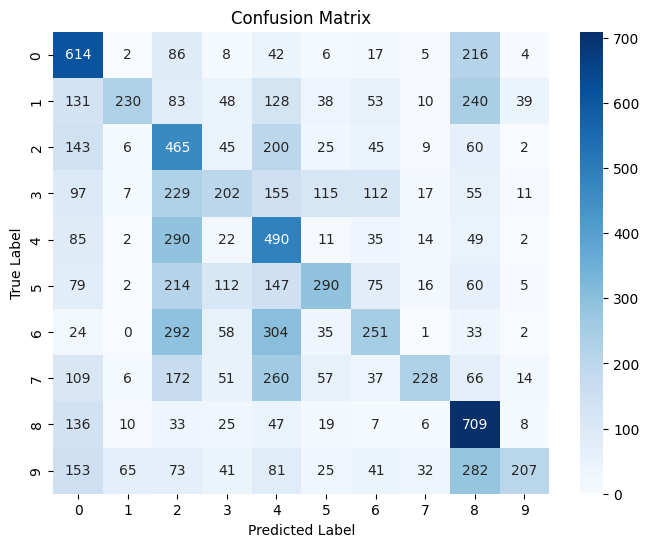

In [18]:
find_knn4()